# Data Exploration

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as ctx
import branca.colormap as c


sns.set_style("whitegrid")

In [42]:
df_buoy = pd.read_csv('output/north_sea_cphl_cleaned.csv')
df = pd.read_csv('data/sentinel_points_combined.csv')

In [43]:
# Check missing values
missing = df.isna().sum().sort_values(ascending=False)
# print(missing.head(30))

# Check valid rows
print("Rows with satellite data:", (df["valid_pixel_count"] > 0).sum())

# Filter out rows with no valid satellite pixels
df = df[df["valid_pixel_count"] > 0]

Rows with satellite data: 6867


In [44]:
df["STATN"].nunique()

120

In [45]:
df.describe()["year"]

count    6867.000000
mean     2020.043542
std         2.361145
min      2016.000000
25%      2018.000000
50%      2020.000000
75%      2022.000000
max      2024.000000
Name: year, dtype: float64

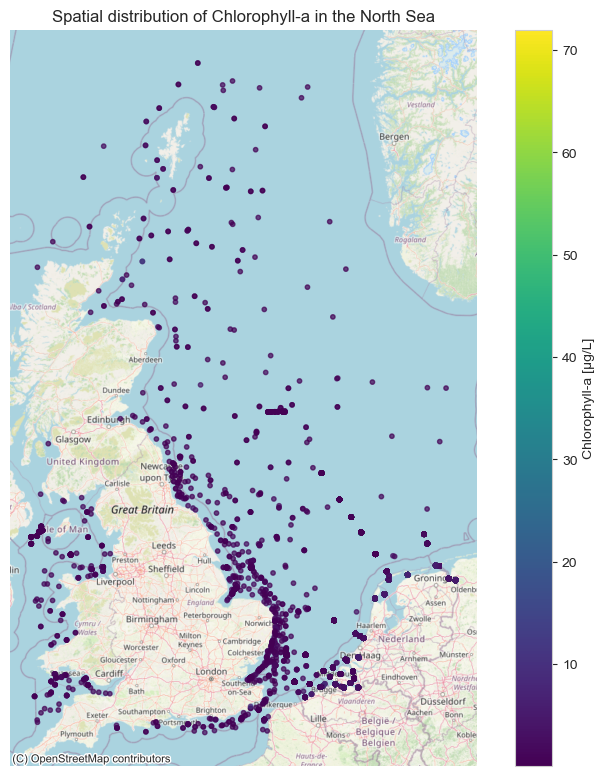

In [47]:
# Remove rows with missing coordinates or chlorophyll values
df_map = df.dropna(subset=["Latitude", "Longitude", "Value"]).copy()

# Convert to GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["Longitude"], df_map["Latitude"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator for basemap compatibility
gdf = gdf.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot chlorophyll points
gdf.plot(
    ax=ax,
    column="Value",
    cmap="viridis",
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': "Chlorophyll-a [µg/L]"}
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.set_title("Spatial distribution of Chlorophyll-a in the North Sea")
fig.tight_layout()

# fig.savefig("chl_map.pdf", bbox_inches="tight")
plt.show()

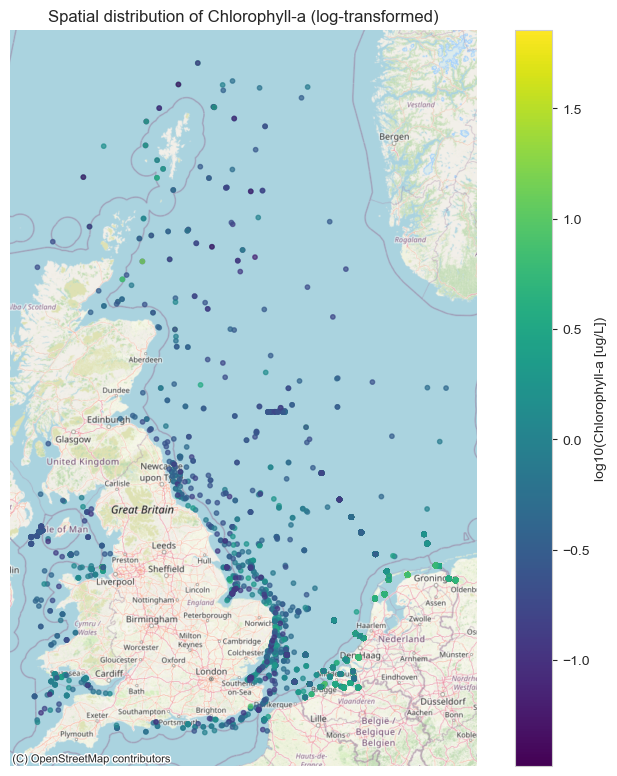

In [48]:
# Remove rows with missing coordinates or chlorophyll values
df_map = df.dropna(subset=["Latitude", "Longitude", "Value"]).copy()

# Log-transform of chlorophyll
df_map["log_chl"] = np.log10(df_map["Value"])

# Convert to GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["Longitude"], df_map["Latitude"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator for basemap compatibility
gdf = gdf.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot chlorophyll points
gdf.plot(
    ax=ax,
    column="log_chl",
    cmap="viridis",
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': "log10(Chlorophyll-a [ug/L])"}
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.set_title("Spatial distribution of Chlorophyll-a (log-transformed)")
fig.tight_layout()

# fig.savefig("chl_map.pdf", bbox_inches="tight")
plt.show()

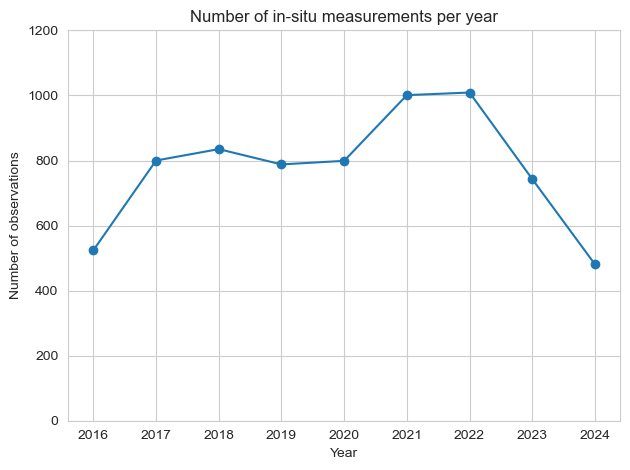

In [7]:
counts_per_year = df.groupby("year").size()

counts_per_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Number of in-situ measurements per year")
plt.ylim(0, 1200)
plt.tight_layout()
plt.show()

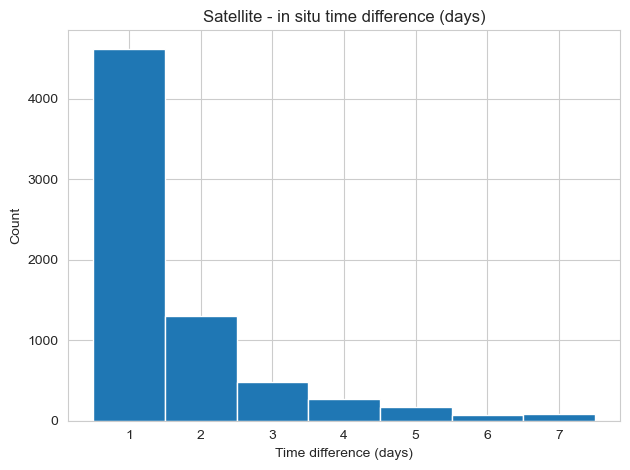

In [ ]:
df["time_diff_days"] = df["sat_time_diff_hours"] / 24

fig, ax = plt.subplots()

ax.hist(df["time_diff_days"].dropna(), bins=7)
ax.set_xlabel("Time difference (days)")
ax.set_ylabel("Count")
ax.set_title("Satellite - in situ time difference (days)")
fig.tight_layout()

fig.savefig("output/Time_difference.pdf")
plt.show()

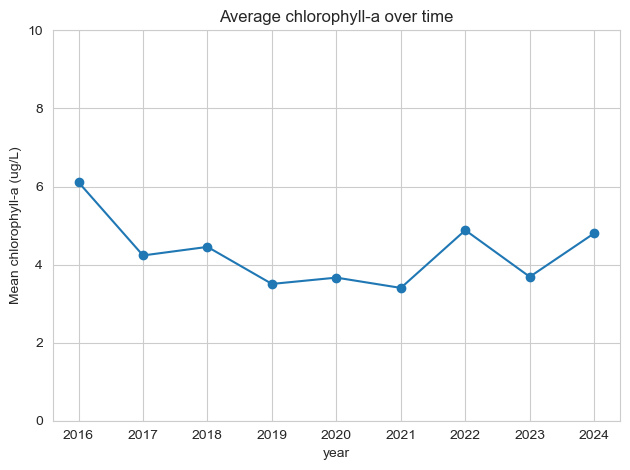

In [9]:
chl_year = df.groupby("year")["Value"].mean()

chl_year.plot(marker="o")
plt.ylabel("Mean chlorophyll-a (ug/L)")
plt.title("Average chlorophyll-a over time")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

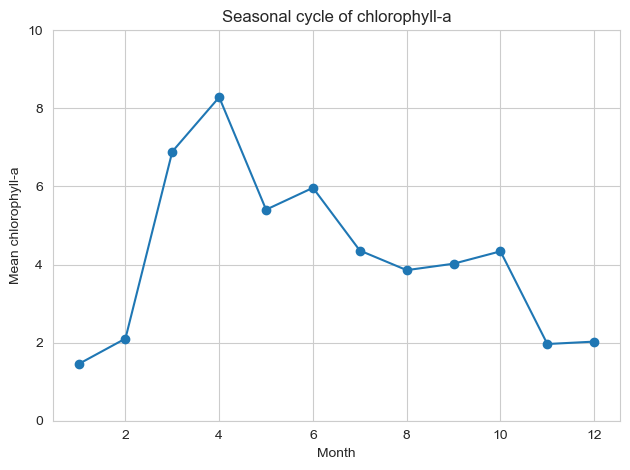

In [ ]:
chl_month = df.groupby("month")["Value"].mean()

fig, ax = plt.subplots()

ax.plot(chl_month.index, chl_month.values, marker="o")

ax.set_xlabel("Month")
ax.set_ylabel("Mean chlorophyll-a")
ax.set_title("Seasonal cycle of chlorophyll-a")
ax.set_ylim(0, 10)

fig.tight_layout()
fig.savefig("output/Chl_seasonal_cycle.pdf", bbox_inches="tight")

plt.show()

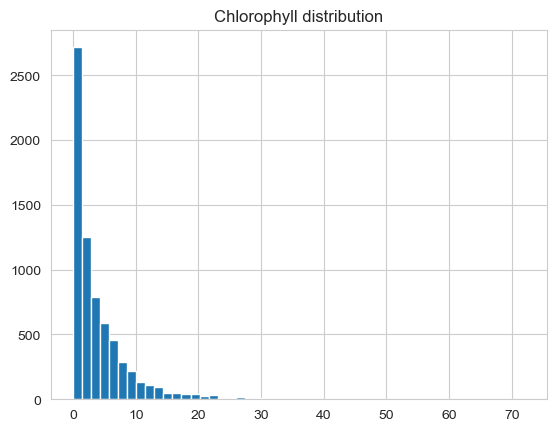

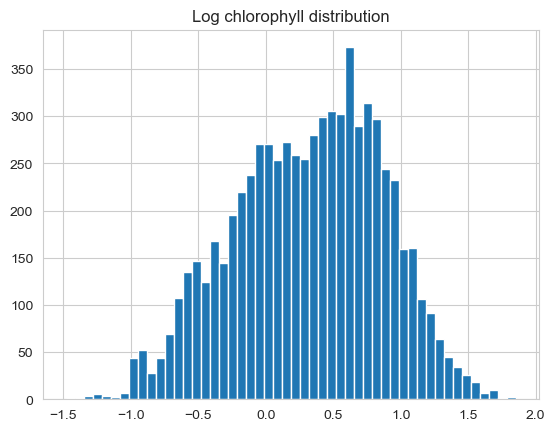

In [12]:
import numpy as np

plt.hist(df["Value"].dropna(), bins=50)
plt.title("Chlorophyll distribution")
plt.show()

# log-scale (veel beter!)
plt.hist(np.log10(df["Value"].dropna()), bins=50)
plt.title("Log chlorophyll distribution")
plt.show()



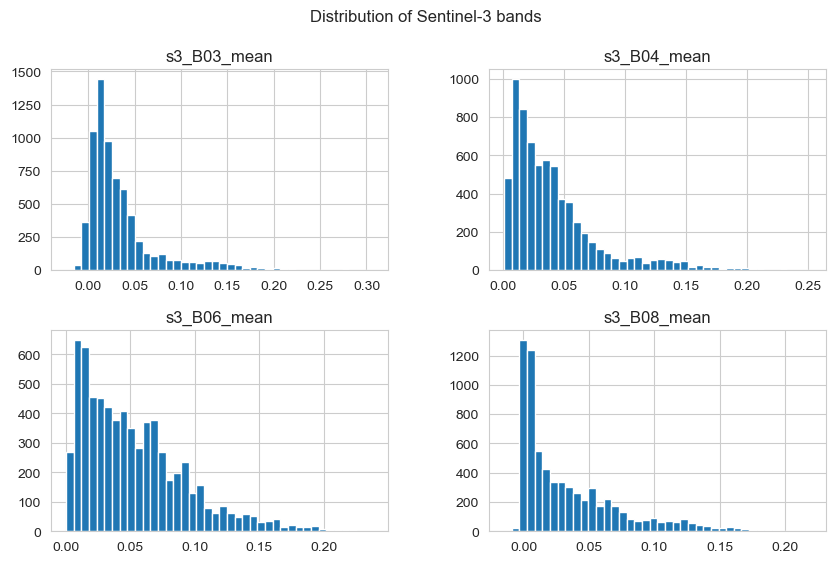

In [13]:
bands = ["s3_B03_mean", "s3_B04_mean", "s3_B06_mean", "s3_B08_mean"]

df[bands].hist(bins=40, figsize=(10,6))
plt.suptitle("Distribution of Sentinel-3 bands")
plt.show()

c:\Users\eveli\.conda\envs\geospatial\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


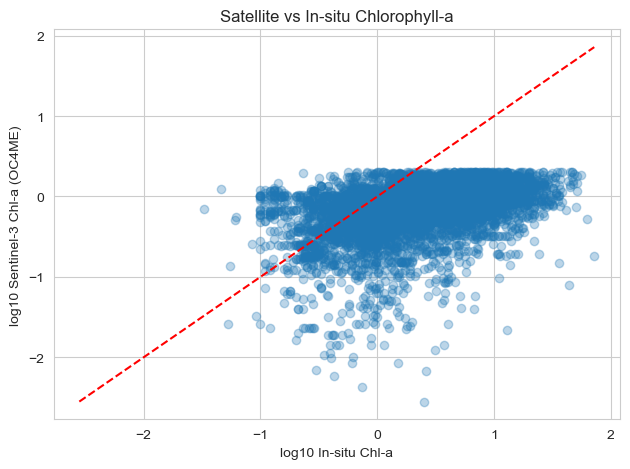

In [ ]:
# Filter data
df_clean = df

# df_clean = df[
#     (df["valid_pixel_count"] > 5) &
#     (df["sat_time_diff_hours"].abs() < 24)
# ].copy()


# Log transform
df_clean["log_insitu"] = np.log10(df_clean["Value"])
df_clean["log_sat"] = np.log10(df_clean["s3_CHL_OC4ME_mean"])

# Create figure
fig, ax = plt.subplots()

ax.scatter(df_clean["log_insitu"], df_clean["log_sat"], alpha=0.3)

lims = [
    min(df_clean["log_insitu"].min(), df_clean["log_sat"].min()),
    max(df_clean["log_insitu"].max(), df_clean["log_sat"].max()),
]

ax.plot(lims, lims, 'r--')

ax.set_xlabel("log10 In-situ Chl-a")
ax.set_ylabel("log10 Sentinel-3 Chl-a (OC4ME)")
ax.set_title("Satellite vs In-situ Chlorophyll-a")

fig.tight_layout()

# Save as high-quality PDF (vector format)
fig.savefig("output/Chl_scatter.pdf")

plt.show()